AI 212 S2 <br>
Acilo, Callagon, Franco, Munar

In [1]:
# !pip install numpy scipy matplotlib -q

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
# inverse special functions for inverse cdf
from scipy.special import erfinv, betaincinv
from IPython.display import Image

In [3]:
SEED = 2025 # for reproducibility

In [4]:
# numpy exposes a class for Mersenne Twister pseudo-random number generator.
# 'rng' serves as a generator of random numbers with method `.random()`
# that helps us to generate X uniform random numbers from 0 to 1

bit_generator = np.random.MT19937(seed=SEED)
rng = np.random.Generator(bit_generator)

# 1. Random number generation (Mersenne Twister)

a. Research the MT19937 (Mersenne Twister) algorithm for generating uniform random numbers. Provide a discussion on its features, period length, and efficiency compared to other random number generators such as linear congruential generators (LCG) and hardware-based generators. Consider discussing real-world applications where MT19937 is commonly used and any potential limitations it may have.

b. Using the MT19937 algorithm, write a program that generates N samples from each of the following continuous distributions: <br>
- Uniform(a, b)
- Exponential($\lambda$)
- Normal($\mu$, $\sigma$^2)
- Any other continuous distribution

Explain the process of transforming uniform random numbers into these distributions. Provide clear mathematical justifications for the transformations used (e.g., inverse transform sampling, Box-Muller method for normal distribution). Plot the histograms of your generated samples and compare them with theoretical probability density functions (PDFs). Discuss any discrepancies and potential reasons for deviations.

**Discussion on RNGs and Mersenne Twister (MT19937)**

- There are two kinds of random number generator (RNG), pseudorandom RNG and true RNG. PRNG makes use of deterministic mathematical algorithms to generate random numbers while TRNG makes use of various unpredictable physical phenomena (see high-level overview in the mermaid chart below).<br>

- What makes a good RNG?
    
    - Should be unpredictable <br>
    - Should follow a uniform distribution <br>
    - Should have a long period <br>
    - Should be consistent across seeds <br><br>

Period: $ p = 2^{19937} – 1 $

<br>


- The MT19937 algorithm is classified as a pseudorandom RNG. It helps us to generate uniform random numbers ~ U(0, 1). <br>

    - **Period:** All RNGs have a finite period. MT19937 has a period of $ p = 2^{19937} – 1 $, it can produce a sequence of 32-bit integers that only repeats itself after $ p $ numbers have been generated.
    - **Speed:** The MT19937 algorithm is relatively faster than other PRNGs, making it suitable for applications that require generating large quantities of random numbers quickly (e.g. computer simulation, 3d graphics, game development, etc.). See speed comparison ([here](https://vorbrodt.blog/2019/02/24/random-number-generator/)).
    - **Seed:** The MT19937 engine accepts only a single 32-bit integer as the seed (controls reproducibility), which limits the number of possible random sequences to 2^32. <br><br>

- Major limitation of PRNGs (including MT19937) is they are **not cryptographically secure**. A bad actor can potentially predict the sequence if they know the seed.

- How does MT compare to Linear Congruential Generator (LCG)?

    - **Period.** MT has a much longer period than LCG; LCG has a period of $ X_{n+1} = (a \ X_{n} + c) \  mod \ m $
        - $ a $ is the multiplier, $ \ $ $ 0 < a < m $
        - $ c $ is the increment, $ \ $ $ 0 \leq c < m $
        - $ X_{0} $ is the seed, $ \ $ $ 0 \leq X_{0} < m $
        - $ m $ is the modulus, $ 0 < m $ <br>
    - **Application.** MT is used for applications requiring high-quality pseudorandom numbers (i.e. computer simulations) and use LCG for applications where the speed is paramount concern and statistical robustness is less critical.
    - **Complexity.** MT is a much more complex algorithm than LCG. MT maintains its state in an array of 624 32-bit integers, which requires significant memory and careful management to ensure the sequence's quality and unpredictability.
    - **Speed / Robustness.** MT is computationally slower compared to LCG but is has better statistical properties (i.e. more robust from testing).<br><br>

- Hardware-based generators on the other hand or TRNGs extract randomness from physical processes that behave in a fundamentally non-deterministic way. TRNGs are constructed in such a way that correlation among bits generated in the hardware-level is small making them "truly random".

    - Atmospheric and thermal noise fall under the category of noise-based RNGs. For example, the latter is governed by the Johnson’s eﬀect which creates random voltage on terminals of any resistive material which is held at a temperature higher than absolute zero. Johnson’s noise is due to random thermal motion of the quantized charges. In general, the random analog voltage is sampled periodically and compared to a pre-defined threshold: if higher then “1” is generated, otherwise “0” is generated.
    - Chaos-based TRNGs leverage chaotic systems (by means of optical, electrical, or both). Recent state-of-the-art makes use of ultrawide band chaotic laser where the light intensity of the chaotic laser is the source of randomness. This are usually coupled with XOR circuits in a master-slave format.
    - Quantum-based TRNGs makes use of the building blocks of a quantum computer, the qubit. The qubit can be thought of as a linear combination of two bit values: 0 and 1. When a certain type of measurement is performed on a qubit it will “project” to either pure 0 or pure 1 state in the basis in which measurement has been carried out. Photons are used in QRNGs because they are easy to create, manipulate and detect.

In [5]:
Image(url="https://www.dropbox.com/scl/fi/nwqgrlduv62zzoczxvos3/rng_examples_mermaid.png?rlkey=1u44931gms1ou1l72s2haft39&st=0kw759wu&raw=1")

LIST OF UTILITY FUNCTIONS

In [6]:
# allowed pairs of distribution/method; for the normal distribution we also epxlored box muller on top of inverse cdf
# in some distributions (i.e. normal and beta) we used inverse special functions from scipy because otherwise we have
# to implement a numerical solution for root finding; these distributions do not have closed-form for the inverse CDFs

ERROR = ValueError("""
Select 'distribution'-'method' pair from the following: {('uniform'-'inverse cdf'), ('exponential'-'inverse cdf'), ('normal'-'inverse cdf'), ('normal'-'box muller'), ('beta'-'inverse cdf')}
""")

def generate_distribution(params, sample_size, seed, debug=False):
    global ERROR
    sample_size = int(sample_size)
    bit_generator = np.random.MT19937(seed)
    rng = np.random.Generator(bit_generator)
    distribution = params["distribution"]
    method = params["method"]
    if distribution=="normal":
        mu, sigma = params["mu"], params["sigma"]
        if method == "box muller":
            # take two equal sets of uniform random numbers from `size//2`
            u1, u2 = rng.random(sample_size//2), rng.random(sample_size//2)
            # apply box-muller transform, see formula on discussion below
            z1 = np.sqrt(-2 * np.log(u1)) * np.cos(2 * np.pi * u2)
            z2 = np.sqrt(-2 * np.log(u1)) * np.sin(2 * np.pi * u2)
            samples = np.concatenate((z1, z2)) * sigma + mu
            if debug:
                # add a debug method to visualize the
                # intermediate steps (plotting u1, u2)
                return (u1, u2), (z1, z2), samples
            else:
                return samples
        elif method == "inverse cdf":
            u = rng.random(sample_size)
            # we use a special inverse function 'erfinv' since normal
            # distribution does not have an explicit closed form
            samples = mu + sigma * np.sqrt(2) * erfinv(2 * u - 1)
        else:
            raise ERROR
    elif distribution == "uniform" and method == "inverse cdf":
        a, b = params["a"], params["b"]
        u = rng.random(sample_size)
        samples = samples = a + (b - a) * u
    elif distribution == "exponential" and method == "inverse cdf":
        # replaced lambda (python reserved keyword) with lambdain
        lambdain = params["lambdain"]
        u = rng.random(sample_size)
        samples = -np.log(u) / lambdain
    elif distribution == "beta" and method == "inverse cdf":
        alpha, beta = params["alpha"], params["beta"]
        u = rng.random(sample_size)
        # used scipy to implement the inverse beta function
        samples = betaincinv(alpha, beta, u)
    else:
        raise ERROR
    return samples

def normal_theoretical_pdf(mu, sigma):
    # see pdf formula in the normal subsection
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1_000)
    y = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return x, y

def exponential_theoretical_pdf(lambdain):
    # see pdf formula in the exponential subsection
    x = np.linspace(0, 10, 1_000)
    y = lambdain * np.exp(-lambdain * x)
    return x, y

def uniform_theoretical_pdf(a, b):
    # see pdf formula in the uniform subsection
    x_margin = (b - a) * 0.5 if b > a else 1
    x = np.linspace(a - x_margin, b + x_margin, 1_000)
    y = np.where((x >= a) & (x <= b), 1 / (b - a), 0)
    return x, y

def beta_theoretical_pdf(alpha, beta):
    # see pdf formula in the beta subsection
    x = np.linspace(0, 1, 1000)
    B = math.gamma(alpha) * math.gamma(beta) / math.gamma(alpha + beta)
    y = (x**(alpha - 1)) * ((1 - x)**(beta - 1)) / B
    return x, y

def plot_generated_vs_theoretical_pdf(samples, params):
    global ERROR
    plt.hist(samples, bins="auto", density=True)
    distribution, method = params["distribution"], params["method"]
    if distribution == "exponential" and method == "inverse cdf":
        lambdain = params["lambdain"]
        x, y = exponential_theoretical_pdf(lambdain)
        plt.title(fr"exponential($\lambda$={lambdain}) | method='{method}'")
    elif distribution == "uniform" and method == "inverse cdf":
        a, b = params["a"], params["b"]
        x, y = uniform_theoretical_pdf(a, b)
        plt.title(f"uniform(a={a}, b={b}) | method='{method}'")
    elif distribution == "normal" and method in ("inverse cdf", "box muller"):
        mu, sigma = params["mu"], params["sigma"]
        x, y = normal_theoretical_pdf(mu, sigma)
        plt.title(fr"normal($\mu$={mu}, $\sigma$^2={sigma**2}) | method='{method}'")
    elif distribution == "beta" and method == "inverse cdf":
        alpha, beta = params["alpha"], params["beta"]
        x, y = beta_theoretical_pdf(alpha, beta)
        plt.title(fr"beta($\alpha$={alpha}, $\beta$={beta}) | method='{method}'")
    else:
        raise ERROR
    plt.plot(x, y, "r-", lw=2)
    plt.legend(["theoretical pdf", "generated samples"])
    plt.ylabel("density")

**Inverse Transform Sampling with MT19937**

NOTE: Inverse Transform Sampling is also called Quantile Function Method

Suppose we are interested in a random variable $ X $ whose cdf is $ F $, then

$ X = F^{-1}(U) $ , where $ F^{-1} $ is the inverse of $ F $ and $ U $ is a continuous uniform distribution between 0 and 1

$ F $ then should be:
- known and written in its closed form
- continuous
- strictly increasing

The algorithm to simulate observations from a random variable $ X $ with distribution $ F $
- compute the inverse $ F^{-1} $ of $ F $
- generate independent random observations $ u_{1}, u_{2}, ..., u_{N} $ between 0 and 1 from MT19937
- compute $ x_{1} = F^{-1}(u_{1}), x_{2} = F^{-1}(u_{2}), ..., x_{N} = F^{-1}(u_{N}) $

then $ x_{1}, x_{2}, ..., x_{N} $ are independent random observations of the random variable $ X $

**Uniform(a, b)**

<u>pdf:</u><br><br>
$\displaystyle
\text{f}(x) =
\begin{cases}
\ \frac{1}{b - a} & \text{for} \  x \ge 0 \\
\ 0 & \text{otherwise}
\end{cases}
$

<u>cdf:</u><br><br>
$\displaystyle
\text{F}(x) =
\begin{cases}
\ 0 & \text{for} \  x < a \\
\ \frac{x-a}{b - a} & \text{for} \  a \le x \le b \\
\ 1 & \text{for} \ x > b
\end{cases}
$

<u>inverse cdf:</u><br><br>
$ F^{-1}(u) = a + (b - a)u \ \ \text{for } u \in [0, 1] $

<u>mean:</u><br><br> $ \mu = \frac{a + b}{2}$

<u>variance:</u><br><br> $ \sigma^{2} = \frac{(b - a)^{2}}{12}$

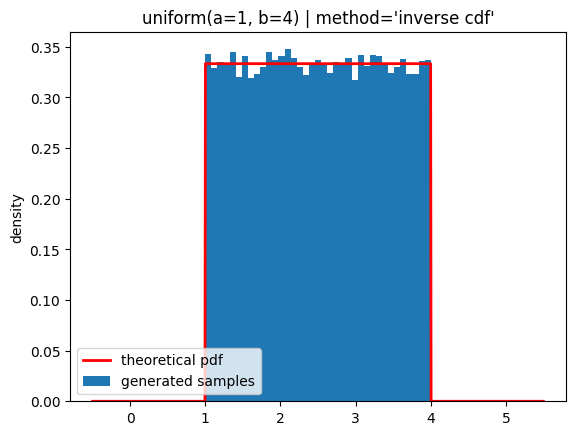

In [7]:
sample_size = 50_000
params = {"distribution": "uniform", "method": "inverse cdf", "a": 1,  "b": 4}
samples = generate_distribution(params, sample_size, SEED)

plot_generated_vs_theoretical_pdf(samples, params)

In [8]:
a, b = params["a"], params["b"]

# sanity check on variance
experimental_var = np.std(samples)**2
print(f"input/expected var: {((b-a)**2)/12}\nexperimental var: {experimental_var}\n")
assert np.isclose(experimental_var, ((b-a)**2)/12, rtol=1e-02)

# sanity check on mean
experimental_mean = np.mean(samples)
print(f"input/expected mean: {(a+b)/2}\nexperimental mean: {experimental_mean}")
assert np.isclose(experimental_mean, (a+b)/2, rtol=1e-02)

print("The uniform distributions (generated vs theoretical) match!")

input/expected var: 0.75
experimental var: 0.7498878690574513

input/expected mean: 2.5
experimental mean: 2.4978434540299075
The uniform distributions (generated vs theoretical) match!


**Exponential($\lambda$)**

<u>pdf:</u><br><br>
$\displaystyle
\text{f}(x) =
\begin{cases}
\ \lambda e^{- \lambda x} & \text{for} \  x \ge 0 \\
\ 0 & \text{otherwise}
\end{cases}
$

<u>cdf:</u><br><br>
$\displaystyle
\text{F}(x) =
\begin{cases}
\ 0 & \text{for} \  x < 0 \\
\ 1 - e^{- \lambda x} & \text{for} \  x \ge 0
\end{cases}
$

<u>inverse cdf:</u><br><br>
$ F^{-1}(u) = -\frac{1}{\lambda} \ln(1 - u) \ \ \text{for } u \in (0, 1) $ <br><br>
if $ u \sim (0, 1) $ then so is $ 1 - u $ <br>
$ F^{-1}(u) = -\frac{1}{\lambda} \ln(u) $

<u>mean:</u><br><br> $ \mu = \frac{1}{\lambda} $

<u>variance:</u><br><br> $ \sigma^{2} = \frac{1}{\lambda^{2}} $

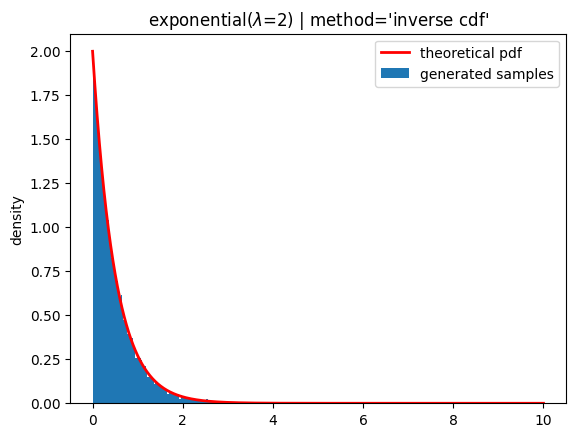

In [9]:
sample_size = 50_000
params = {"distribution": "exponential", "method": "inverse cdf", "lambdain": 2}
samples = generate_distribution(params, sample_size, SEED)

plot_generated_vs_theoretical_pdf(samples, params)

In [10]:
lambdain = params["lambdain"]

# sanity check on variance
experimental_var = np.std(samples)**2
print(f"input/expected var: {1/(lambdain**2)}\nexperimental var: {experimental_var}\n")
assert np.isclose(experimental_var, 1/(lambdain**2), rtol=1e-02)

# sanity check on mean
experimental_mean = np.mean(samples)
print(f"input/expected mean: {1/lambdain}\nexperimental mean: {experimental_mean}")
assert np.isclose(experimental_mean, 1/lambdain, rtol=1e-02)

print("The exponential distributions (generated vs theoretical) match!")

input/expected var: 0.25
experimental var: 0.2498393968164283

input/expected mean: 0.5
experimental mean: 0.5011914183599748
The exponential distributions (generated vs theoretical) match!


**Normal($\mu$, $\sigma^2$)**

<u>pdf:</u><br><br> $ f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}(\frac{x- \mu}{\sigma})^{2}}$

<u>cdf:</u><br><br> $ F(x) = \frac{1}{2} [1 + erf(\frac{x- \mu}{\sigma \sqrt{2}})] $ <br>
$ erf(z) = \frac{2}{\sqrt\pi} \int_0^{z} e^{-t^{2}} dt $

<u>inverse cdf:</u><br><br> $ F^{-1}(u) = \mu + \sigma \sqrt{2} \cdot \operatorname{erf}^{-1}(2u - 1) $

NOTE: There's actually no closed-form for the CDF of the normal distribution, it’s usually evaluated numerically or with special functions like *erf* (from scipy) or approximated using tables.

<u>mean:</u><br><br> $ \mu = \mu$

<u>variance:</u><br><br> $ \sigma^{2} = \sigma^{2}$

**Box-Muller Transform Method with MT19937**

In practice, we favor Box-Muller transform over the inverse cdf / quantile function method for the normal distribution because of computational efficiency. Computing $ \phi^{−1}(u) $ in the inverse cdf approach requires numerical approximation which can be slow. Box-Muller uses only simple and trigonometric math operations. Moreover, Box-Muller directly samples from the shape of the 2D normal distribution (polar coordinates), so it's less prone to edge errors than inverse cdf methods. It's a great option when you have a high-quality uniform PRNG like MT19937. Please see relevant formulas below.

Input:<br> $ U_{1}, U_{2} \sim U(0, 1) $ <br><br>
Output:<br>
$ Z_{1}. Z_{2} \sim N(0, 1) $ <br>
$ Y \sim N(\mu, \sigma^2) $ <br>

where: <br>
$ Z_{1} = \sqrt{-2 \ log(U_{1})} \ cos(2\pi U_{2}) $ <br>
$ Z_{2} = \sqrt{-2 \ log(U_{1})} \ sin(2\pi U_{2}) $ <br>
$ Z1 \ and \ Z2 $ are independent samples from the standard normal pdf

1. MT19937 generates two equal sets of uniform random numbers U1 and U2
2. BMT takes U1 and U2 as input and generates two independent equal sets of standard normal samples Z1 and Z2
3. In order to get the Normal($\mu$, $\sigma$^2) distribution, we concatenate Z1 and Z2 and shift by $\mu$ and stretch by $\sigma$^2

In [11]:
Image(url="https://www.dropbox.com/scl/fi/godmitfkkf8077bqm2h5f/box_muller_mermaid.png?rlkey=ca31yvphbc0oqzjdvw7q3ucnk&st=lb100z65&raw=1")

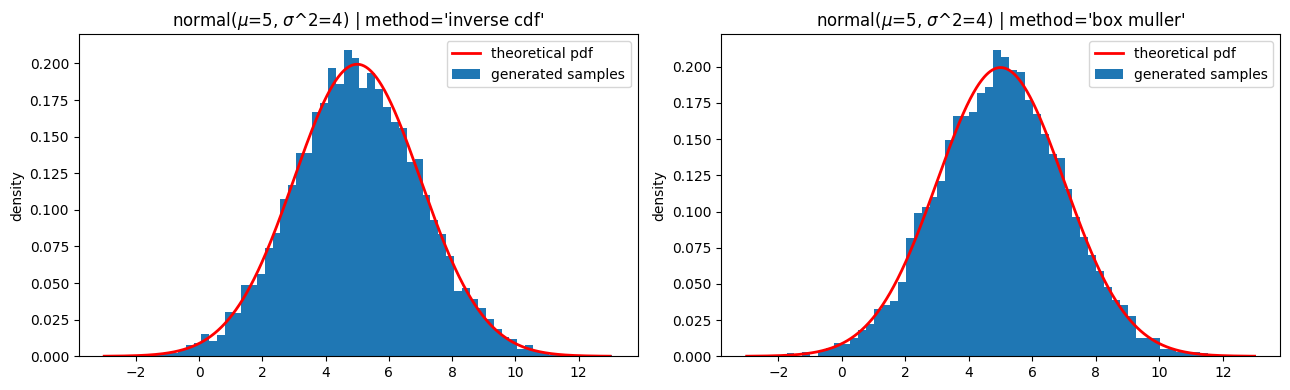

In [12]:
sample_size = 10_000

f = plt.figure(figsize=(13, 4))

f.add_subplot(1, 2, 1)
params = {"distribution": "normal", "method": "inverse cdf", "mu": 5, "sigma": 2}
samples = generate_distribution(params, sample_size, SEED)
plot_generated_vs_theoretical_pdf(samples, params)

f.add_subplot(1, 2, 2)
params = {"distribution": "normal", "method": "box muller", "mu": 5, "sigma": 2}
samples = generate_distribution(params, sample_size, SEED)
plot_generated_vs_theoretical_pdf(samples, params)

plt.tight_layout();

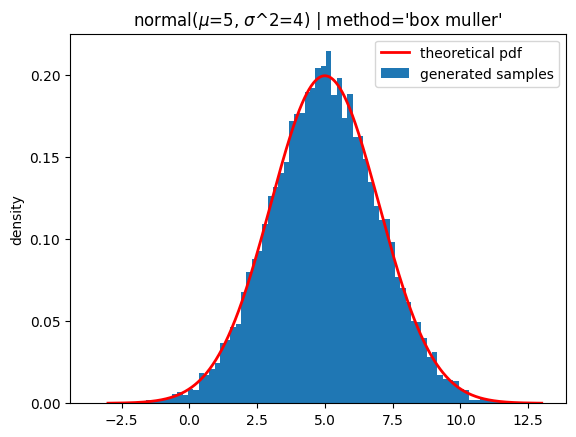

In [13]:
sample_size = 20_000
params = {"distribution": "normal", "method": "box muller", "mu": 5, "sigma": 2}
# i just set the debug parameter to True to visualize U1,U2 and Z1,Z2
(u1, u2), (z1, z2), samples = generate_distribution(params, sample_size, SEED, True)
plot_generated_vs_theoretical_pdf(samples, params)

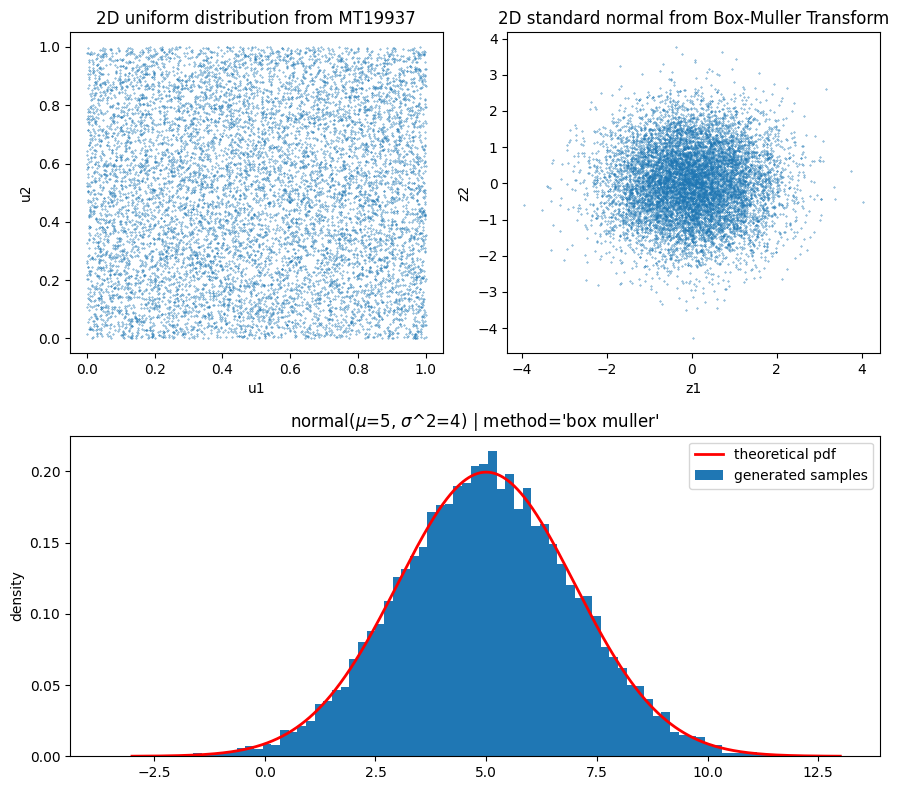

In [14]:
f = plt.figure(figsize=(9, 8))

f.add_subplot(2, 2, 1)
plt.scatter(u1, u2, s=0.1)
plt.xlabel("u1")
plt.ylabel("u2")
plt.title("2D uniform distribution from MT19937")

f.add_subplot(2, 2, 2)
plt.scatter(z1, z2, s=0.1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("2D standard normal from Box-Muller Transform")

f.add_subplot(2, 1, 2)
plot_generated_vs_theoretical_pdf(samples, params)

plt.tight_layout();

1. Top-left figure shows the 2D uniform distribution from our PNRG (should be a box equally filled on all areas with points).
2. Top-right figure shows the 2D standard normal distribution from Box-Muller transform output (should be a gaussian blob).
3. Bottom figure shows the experimental (generated) normal distribution from the MT19937 overlayed with its theoretical pdf.



In [15]:
mu, sigma = params["mu"], params["sigma"]

# sanity check on variance
experimental_var = np.std(samples)**2
print(f"input/expected var: {sigma**2}\nexperimental var: {experimental_var}\n")
assert np.isclose(experimental_var, sigma**2, rtol=1e-02)

# sanity check on mean
experimental_mean = np.mean(samples)
print(f"input/expected mean: {mu}\nexperimental mean: {experimental_mean}")
assert np.isclose(experimental_mean, mu, rtol=1e-02)

print("The normal distributions (generated vs theoretical) match!")

input/expected var: 4
experimental var: 3.982092951725714

input/expected mean: 5
experimental mean: 5.003701904526611
The normal distributions (generated vs theoretical) match!


**Beta($\alpha$, $\beta$)**

<u>pdf:</u><br><br> $ f(x) = \frac{x^{\alpha-1} \ (1-x)^{\beta - 1}}{B(\alpha, \beta)} $<br>
$ B(\alpha, \beta) = \frac{\gamma(\alpha)\gamma(\beta)}{\gamma(\alpha+\beta)} $

<u>cdf:</u><br><br> $ F(x) = I_x(\alpha, \beta) = \frac{1}{B(\alpha, \beta)} \int_0^x t^{\alpha - 1}(1 - t)^{\beta - 1} \, dt $

<u>inverse cdf:</u><br><br> $ F^{-1}(u) = I_u^{-1}(\alpha, \beta) $ <br>
$ I_u^{-1}(\alpha, \beta) $ is the inverse of the regularized incomplete beta function (I used scipy for this step) <br>

<u>mean:</u><br><br> $ \mu = \frac{\alpha}{\alpha + \beta} $

<u>variance:</u><br><br> $ \sigma^{2} = \frac{\alpha \beta}{(\alpha + \beta)^{2} \ (\alpha + \beta + 1)} $

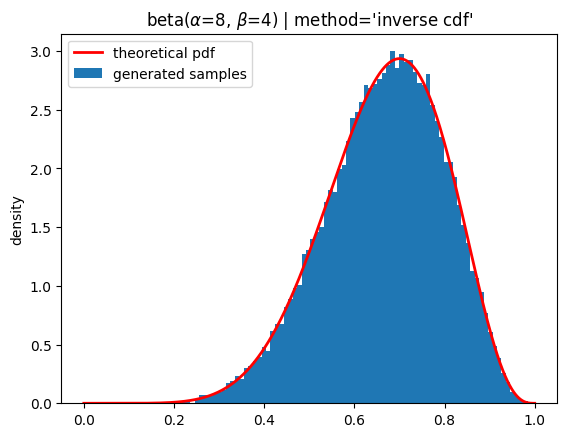

In [16]:
sample_size = 50_000
params = {"distribution": "beta", "method": "inverse cdf", "alpha": 8, "beta": 4}
samples = generate_distribution(params, sample_size, SEED)

plot_generated_vs_theoretical_pdf(samples, params)

In [17]:
alpha, beta = params["alpha"], params["beta"]

# sanity check on variance
experimental_var = np.std(samples)**2
print(f"input/expected var: {(alpha*beta)/((alpha+beta)**2 * (alpha+beta+1))}\nexperimental var: {experimental_var}\n")
assert np.isclose(experimental_var, (alpha*beta)/((alpha+beta)**2 * (alpha+beta+1)), rtol=1e-02)

# sanity check on mean
experimental_mean = np.mean(samples)
print(f"input/expected mean: {alpha/(alpha+beta)}\nexperimental mean: {experimental_mean}")
assert np.isclose(experimental_mean, alpha/(alpha+beta), rtol=1e-02)

print("The beta distributions (generated vs theoretical) match!")

input/expected var: 0.017094017094017096
experimental var: 0.01712767854267165

input/expected mean: 0.6666666666666666
experimental mean: 0.6663468594006432
The beta distributions (generated vs theoretical) match!


**Summary**

We employed MT19937 as a PRNG to generate uniform random samples $ u \sim U(0, 1) $. We can transform these samples into other probabilty distributions using the inverse transform sampling method which requires the inverse cdf of the target distributions (see relevant equations: pdf, cdf, inverse cdf from each subsection). For the normal and beta distribution, they don't have an explicit closed form so we used special inverse functions from scipy (another option is to use a numerical solver).

For the normal distribution, there is a special method called Box-Muller transform which returns two independent standard normals that is radially symmetric in 2D space. This alternative method is computationally efficient since it does not require special inverse functions from the inverse CDF method. We then scale and squish the resulting standard normal with $ \mu $ and $ \sigma $ to arrive at the general normal distribution.

Based on the gathered distributions originating from MT19937, we compared it to their theoretical pdf to see the capability of the discussed techniques to simulate the target distributions. From all the figures shown, the MT-generated distributions all approximated their respective theoretical distributions. We checked the mean and variance (theoretical VS generated) as additional layer of checking to see if they match.

In terms of discrepancies and potential reasons for deviation, (a) having a small sample size introduce more random fluctuations, pulling the MT-generated distribution away from the theoretical pdf (b) the selection of histogram bin size can also introduce "binning artifacts"; in our problem we opted to use the "auto" bins option in matplotlib, that uses the Sturges and Freedman-Diaconis bins, which numpy uses by default (c) numerical precision (float32 vs float64) can also play a role in the discrepancies, primarily from the intermediate inverse cdf calculations.